<a href="https://colab.research.google.com/github/pallu663/Internships-/blob/main/Copy_of_Untitled0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!ls

sample_data


In [ ]:
!unzip rossmann-store-sales.zip

Archive:  rossmann-store-sales.zip
  inflating: sample_submission.csv   
  inflating: store.csv               
  inflating: test.csv                
  inflating: train.csv               


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving rossmann-store-sales.zip to rossmann-store-sales (1).zip


In [ ]:
zip_file = [f for f in os.listdir() if f.endswith('.zip')][0]
print(zip_file)

rossmann-store-sales (1).zip


In [ ]:
import zipfile

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall()

print("Unzipped ✅")

Unzipped ✅


In [ ]:
os.listdir()

['.config',
 'sample_submission.csv',
 'store.csv',
 'train.csv',
 'test.csv',
 '.ipynb_checkpoints',
 'rossmann-store-sales.zip',
 'sample_data']

In [ ]:
df = pd.read_csv('train.csv')

print("Loaded ✅")
print(df.columns)

Loaded ✅
Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday'],
      dtype='object')


/tmp/ipykernel_19078/118434887.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('train.csv')


In [ ]:
# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])

# Sort
df = df.sort_values('Date')

In [ ]:
df['lag_1'] = df['Sales'].shift(1)
df['lag_7'] = df['Sales'].shift(7)
df['lag_30'] = df['Sales'].shift(30)

df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,lag_1,lag_7,lag_30
1017208,1115,2,2013-01-01,0,0,0,0,a,1,NaN,NaN,NaN
1016473,379,2,2013-01-01,0,0,0,0,a,1,0.0,NaN,NaN
1016472,378,2,2013-01-01,0,0,0,0,a,1,0.0,NaN,NaN
1016471,377,2,2013-01-01,0,0,0,0,a,1,0.0,NaN,NaN
1016470,376,2,2013-01-01,0,0,0,0,a,1,0.0,NaN,NaN


In [ ]:
df['rolling_mean_7'] = df['Sales'].rolling(7).mean()
df['rolling_mean_30'] = df['Sales'].rolling(30).mean()

In [ ]:
df['day'] = df['Date'].dt.day
df['month'] = df['Date'].dt.month
df['year'] = df['Date'].dt.year
df['day_of_week'] = df['Date'].dt.dayofweek

df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)

In [ ]:
# 7-day average
df['rolling_mean_7'] = df['Sales'].rolling(window=7).mean()

# 30-day average
df['rolling_mean_30'] = df['Sales'].rolling(window=30).mean()

df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,lag_1,lag_7,lag_30,rolling_mean_7,rolling_mean_30,day,month,year,day_of_week,is_weekend
1016444,350,2,2013-01-01,0,0,0,0,a,1,0.0,0.0,0.0,NaN,NaN,1,1,2013,1,0
1016458,364,2,2013-01-01,0,0,0,0,a,1,0.0,0.0,0.0,NaN,NaN,1,1,2013,1,0
1016475,381,2,2013-01-01,0,0,0,0,a,1,0.0,0.0,0.0,NaN,NaN,1,1,2013,1,0
1016476,382,2,2013-01-01,0,0,0,0,a,1,0.0,0.0,0.0,NaN,NaN,1,1,2013,1,0
1016477,383,2,2013-01-01,0,0,0,0,a,1,0.0,3139.0,0.0,NaN,NaN,1,1,2013,1,0


In [ ]:
df['day'] = df['Date'].dt.day
df['month'] = df['Date'].dt.month
df['year'] = df['Date'].dt.year
df['day_of_week'] = df['Date'].dt.dayofweek

# Weekend flag
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,lag_1,lag_7,lag_30,rolling_mean_7,rolling_mean_30,day,month,year,day_of_week,is_weekend
1016444,350,2,2013-01-01,0,0,0,0,a,1,0.0,0.0,0.0,NaN,NaN,1,1,2013,1,0
1016458,364,2,2013-01-01,0,0,0,0,a,1,0.0,0.0,0.0,NaN,NaN,1,1,2013,1,0
1016475,381,2,2013-01-01,0,0,0,0,a,1,0.0,0.0,0.0,NaN,NaN,1,1,2013,1,0
1016476,382,2,2013-01-01,0,0,0,0,a,1,0.0,0.0,0.0,NaN,NaN,1,1,2013,1,0
1016477,383,2,2013-01-01,0,0,0,0,a,1,0.0,3139.0,0.0,NaN,NaN,1,1,2013,1,0


In [ ]:
# Example Indian holidays
holidays = pd.to_datetime([
    '2023-01-26',  # Republic Day
    '2023-08-15',  # Independence Day
    '2023-10-02'   # Gandhi Jayanti
])

df['is_holiday'] = df['Date'].isin(holidays).astype(int)

df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,lag_1,lag_7,lag_30,rolling_mean_7,rolling_mean_30,day,month,year,day_of_week,is_weekend,is_holiday
1017196,1103,2,2013-01-01,0,0,0,0,a,1,0.0,0.0,0.0,0.0,198.7,1,1,2013,1,0,0
1017197,1104,2,2013-01-01,0,0,0,0,a,1,0.0,0.0,0.0,0.0,198.7,1,1,2013,1,0,0
1017198,1105,2,2013-01-01,0,0,0,0,a,1,0.0,0.0,0.0,0.0,198.7,1,1,2013,1,0,0
1017199,1106,2,2013-01-01,0,0,0,0,a,1,0.0,0.0,0.0,0.0,198.7,1,1,2013,1,0,0
1017159,1066,2,2013-01-01,0,0,0,0,a,1,0.0,0.0,0.0,0.0,198.7,1,1,2013,1,0,0


In [ ]:
# If promotion column not available, create dummy one
if 'promotion' not in df.columns:
    df['promotion'] = np.random.randint(0, 2, len(df))

In [ ]:
import pandas as pd

train = pd.read_csv('train.csv')
store = pd.read_csv('store.csv')

/tmp/ipykernel_19078/1275727888.py:3: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv('train.csv')


In [ ]:
df = pd.merge(train, store, on='Store', how='left')

In [ ]:
df = pd.get_dummies(df, columns=['StoreType', 'Assortment'], drop_first=True)

df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,CompetitionDistance,...,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,StoreType_b,StoreType_c,StoreType_d,Assortment_b,Assortment_c
0,1,5,2015-07-31,5263,555,1,1,0,1,1270.0,...,2008.0,0,NaN,NaN,NaN,False,True,False,False,False
1,2,5,2015-07-31,6064,625,1,1,0,1,570.0,...,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",False,False,False,False,False
2,3,5,2015-07-31,8314,821,1,1,0,1,14130.0,...,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",False,False,False,False,False
3,4,5,2015-07-31,13995,1498,1,1,0,1,620.0,...,2009.0,0,NaN,NaN,NaN,False,True,False,False,True
4,5,5,2015-07-31,4822,559,1,1,0,1,29910.0,...,2015.0,0,NaN,NaN,NaN,False,False,False,False,False


In [ ]:
# Remove rows with NaN (created due to lag/rolling)
df = df.dropna()

In [ ]:
# Remove rows with NaN (created due to lag/rolling)
df = df.dropna()

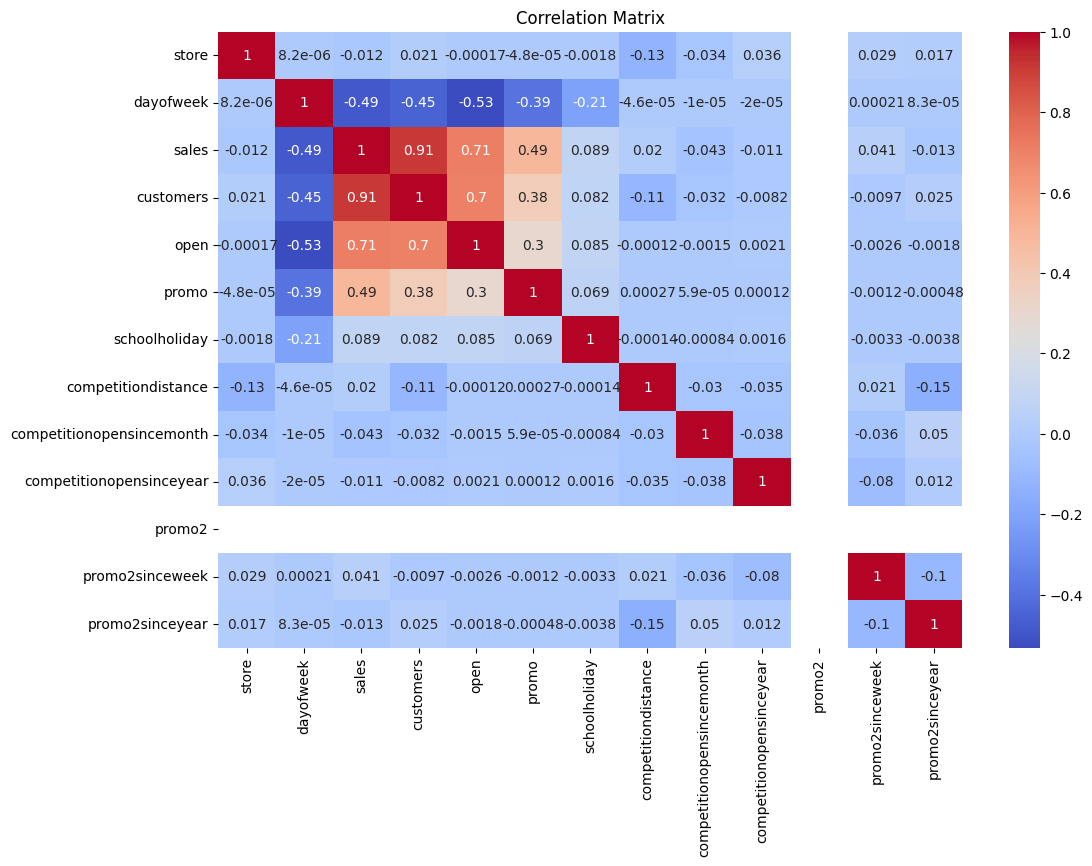

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

# Plot heatmap
plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

In [ ]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 324326 entries, 1 to 1017204
Data columns (total 21 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   store                      324326 non-null  int64  
 1   dayofweek                  324326 non-null  int64  
 2   date                       324326 non-null  object 
 3   sales                      324326 non-null  int64  
 4   customers                  324326 non-null  int64  
 5   open                       324326 non-null  int64  
 6   promo                      324326 non-null  int64  
 7   stateholiday               324326 non-null  object 
 8   schoolholiday              324326 non-null  int64  
 9   competitiondistance        324326 non-null  float64
 10  competitionopensincemonth  324326 non-null  float64
 11  competitionopensinceyear   324326 non-null  float64
 12  promo2                     324326 non-null  int64  
 13  promo2sinceweek            324326